# 01 Data Understanding

Sprint 1 — exploratory analysis of the raw Transfermarkt CSVs.

This notebook is a thin wrapper around `src/load_data.py`. All reusable logic lives there; the notebook only orchestrates and visualises.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.config import METRICS_DIR, RAW_DATA_DIR
from src.load_data import (
    build_data_summary,
    load_raw_datasets,
    save_data_summary,
    summarize_dataframe,
)

In [2]:
datasets = load_raw_datasets(RAW_DATA_DIR)
{name: df.shape for name, df in datasets.items()}

Loading raw datasets from C:\football_market_value-dl\data\raw
  loaded players.csv.gz: shape=(47637, 26)
  loaded player_valuations.csv.gz: shape=(507815, 6)
  loaded appearances.csv.gz: shape=(1877839, 13)
  loaded games.csv.gz: shape=(88271, 23)
  loaded clubs.csv.gz: shape=(796, 17)
  loaded competitions.csv.gz: shape=(67, 11)


{'players': (47637, 26),
 'player_valuations': (507815, 6),
 'appearances': (1877839, 13),
 'games': (88271, 23),
 'clubs': (796, 17),
 'competitions': (67, 11)}

## Per-table overview

In [3]:
for name, df in datasets.items():
    print(f'\n=== {name} ===')
    print('shape  :', df.shape)
    print('columns:', list(df.columns))
    display(df.head())
    if len(df):
        nulls = (df.isna().mean() * 100).round(2)
        nulls = nulls[nulls > 0].sort_values(ascending=False)
        if not nulls.empty:
            print('null %% (>0):')
            display(nulls)


=== players ===
shape  : (47637, 26)
columns: ['player_id', 'first_name', 'last_name', 'name', 'last_season', 'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth', 'country_of_citizenship', 'date_of_birth', 'sub_position', 'position', 'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name', 'image_url', 'international_caps', 'international_goals', 'current_national_team_id', 'url', 'current_club_domestic_competition_id', 'current_club_name', 'market_value_in_eur', 'highest_market_value_in_eur']


,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,agent_name,image_url,international_caps,international_goals,current_national_team_id,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,1000000.0,30000000.0
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,750000.0,8000000.0
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,1000000.0,34500000.0
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus Football Club,200000.0,24500000.0
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,IFM,https://img.a.transfermarkt.technology/portrai...,NaN,NaN,NaN,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,FC Bayern München,100000.0,3000000.0


null %% (>0):


current_national_team_id                94.84
international_goals                     63.22
international_caps                      63.22
agent_name                              46.33
contract_expiration_date                34.45
market_value_in_eur                     33.86
highest_market_value_in_eur             33.86
country_of_birth                        10.83
foot                                    10.70
city_of_birth                           10.25
height_in_cm                             7.70
first_name                               6.48
current_club_name                        4.77
current_club_domestic_competition_id     4.77
sub_position                             0.97
country_of_citizenship                   0.57
date_of_birth                            0.10
dtype: float64


=== player_valuations ===
shape  : (507815, 6)
columns: ['player_id', 'date', 'market_value_in_eur', 'current_club_name', 'current_club_id', 'player_club_domestic_competition_id']


...

total_market_value       100.00
coach_name                88.69
foreigners_percentage      7.29
average_age                4.77
dtype: float64


=== competitions ===
shape  : (67, 11)
columns: ['competition_id', 'competition_code', 'name', 'sub_type', 'type', 'country_id', 'country_name', 'domestic_league_code', 'confederation', 'total_clubs', 'url']


,competition_id,competition_code,name,sub_type,type,country_id,country_name,domestic_league_code,confederation,total_clubs,url
0,A1,bundesliga,bundesliga,first_tier,domestic_league,127,Austria,A1,europa,12.0,https://www.transfermarkt.co.uk/bundesliga/sta...
1,AFAC,afc-asian-cup,afc-asian-cup,afc_asian_cup,national_team_competition,-1,NaN,NaN,asien,NaN,https://www.transfermarkt.co.uk/afc-asian-cup/...
2,AFCN,africa-cup-of-nations,africa-cup-of-nations,africa_cup_of_nations,national_team_competition,-1,NaN,NaN,afrika,NaN,https://www.transfermarkt.co.uk/africa-cup-of-...
3,ARG1,torneo-apertura,torneo-apertura,first_tier,domestic_league,9,Argentina,ARG1,amerika,30.0,https://www.transfermarkt.co.uk/torneo-apertur...
4,AUS1,a-league-men,a-league-men,first_tier,domestic_league,12,Australia,AUS1,asien,12.0,https://www.transfermarkt.co.uk/a-league-men/s...


null %% (>0):


total_clubs             23.88
country_name            19.40
domestic_league_code    19.40
dtype: float64

## Player valuations: temporal range

range: 2000-01-20 00:00:00 -> 2026-02-27 00:00:00


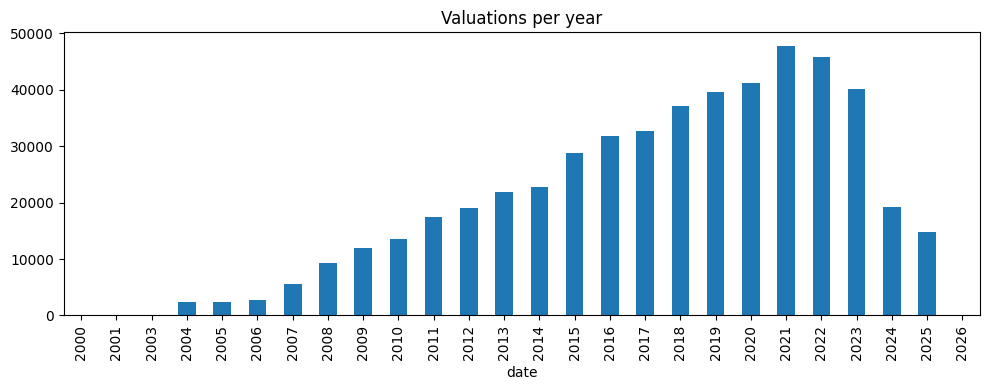

In [4]:
pv = datasets['player_valuations']
date_col = next((c for c in ('date', 'datetime', 'valuation_date') if c in pv.columns), None)
if date_col is not None:
    parsed = pd.to_datetime(pv[date_col], errors='coerce')
    print('range:', parsed.min(), '->', parsed.max())
    parsed.dt.year.value_counts().sort_index().plot(kind='bar', figsize=(10, 4), title='Valuations per year')
    plt.tight_layout()
    plt.show()

## Build and persist `data_summary.json`

In [5]:
summary = build_data_summary(datasets)
save_data_summary(summary, METRICS_DIR / 'data_summary.json')
summary

Summary written to C:\football_market_value-dl\reports\metrics\data_summary.json


{'players': {'rows': 47637,
  'columns': 26,
  'column_names': ['player_id',
   'first_name',
   'last_name',
   'name',
   'last_season',
   'current_club_id',
   'player_code',
   'country_of_birth',
   'city_of_birth',
   'country_of_citizenship',
   'date_of_birth',
   'sub_position',
   'position',
   'foot',
   'height_in_cm',
   'contract_expiration_date',
   'agent_name',
   'image_url',
   'international_caps',
   'international_goals',
   'current_national_team_id',
   'url',
   'current_club_domestic_competition_id',
   'current_club_name',
   'market_value_in_eur',
   'highest_market_value_in_eur'],
  'null_percentage': {'player_id': 0.0,
   'first_name': 6.48,
   'last_name': 0.0,
   'name': 0.0,
   'last_season': 0.0,
   'current_club_id': 0.0,
   'player_code': 0.0,
   'country_of_birth': 10.83,
   'city_of_birth': 10.25,
   'country_of_citizenship': 0.57,
   'date_of_birth': 0.1,
   'sub_position': 0.97,
   'position': 0.0,
   'foot': 10.7,
   'height_in_cm': 7.7,
   'c